In [22]:
import os
import h5py
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


In [23]:
class PatchCamCycleDataset(Dataset):
    def __init__(self, x_path, y_path, domain):
        self.x_path = x_path
        self.y_path = y_path
        self.domain = domain  # 0 = normal, 1 = tumor

        self.indices = []
        with h5py.File(self.y_path, "r") as fy:
            labels = fy["y"][:]
            for i in range(len(labels)):
                if labels[i] == domain:
                    self.indices.append(i)

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        real_idx = self.indices[idx]
        with h5py.File(self.x_path, "r") as fx:
            img = fx["x"][real_idx]

        img = torch.tensor(img).permute(2, 0, 1).float()
        img = img / 127.5 - 1.0   # [-1, 1]

        return img


In [41]:
from torch.utils.data import DataLoader

# -----------------------------
# CONFIG
# -----------------------------
BATCH_SIZE =   6     # keep small for Kaggle GPU
NUM_WORKERS = 0       # 🚨 MUST be 0 for HDF5

X_PATH = "/kaggle/input/patchcam-dataset/camelyonpatch_level_2_split_train_x.h5"
Y_PATH = "/kaggle/input/patchcam-dataset/camelyonpatch_level_2_split_train_y.h5"

# -----------------------------
# DATASETS (CycleGAN Domains)
# -----------------------------
dataset_A = PatchCamCycleDataset(
    x_path=X_PATH,
    y_path=Y_PATH,
    domain=0   # Normal
)

dataset_B = PatchCamCycleDataset(
    x_path=X_PATH,
    y_path=Y_PATH,
    domain=1   # Tumor
)

# -----------------------------
# DATALOADERS
# -----------------------------
loader_A = DataLoader(
    dataset_A,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=False,
    drop_last=True
)

loader_B = DataLoader(
    dataset_B,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=False,
    drop_last=True
)

print(f"Domain A (Normal) samples: {len(dataset_A)}")
print(f"Domain B (Tumor) samples: {len(dataset_B)}")
print("✅ DataLoaders ready for CycleGAN training")


Domain A (Normal) samples: 131072
Domain B (Tumor) samples: 131072
✅ DataLoaders ready for CycleGAN training


In [15]:
class ResBlock(nn.Module):
    def __init__(self, c):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(c, c, 3, padding=1),
            nn.InstanceNorm2d(c),
            nn.ReLU(inplace=True),
            nn.Conv2d(c, c, 3, padding=1),
            nn.InstanceNorm2d(c)
        )

    def forward(self, x):
        return x + self.block(x)


In [16]:
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Conv2d(3, 64, 7, padding=3),
            nn.InstanceNorm2d(64),
            nn.ReLU(True),

            nn.Conv2d(64, 128, 3, stride=2, padding=1),
            nn.InstanceNorm2d(128),
            nn.ReLU(True),

            nn.Conv2d(128, 256, 3, stride=2, padding=1),
            nn.InstanceNorm2d(256),
            nn.ReLU(True),

            ResBlock(256),
            ResBlock(256),
            ResBlock(256),

            nn.ConvTranspose2d(256, 128, 3, stride=2, padding=1, output_padding=1),
            nn.InstanceNorm2d(128),
            nn.ReLU(True),

            nn.ConvTranspose2d(128, 64, 3, stride=2, padding=1, output_padding=1),
            nn.InstanceNorm2d(64),
            nn.ReLU(True),

            nn.Conv2d(64, 3, 7, padding=3),
            nn.Tanh()
        )

    def forward(self, x):
        return self.model(x)


In [17]:
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Conv2d(3, 64, 4, stride=2, padding=1),
            nn.LeakyReLU(0.2, True),

            nn.Conv2d(64, 128, 4, stride=2, padding=1),
            nn.InstanceNorm2d(128),
            nn.LeakyReLU(0.2, True),

            nn.Conv2d(128, 256, 4, stride=2, padding=1),
            nn.InstanceNorm2d(256),
            nn.LeakyReLU(0.2, True),

            nn.Conv2d(256, 1, 4, padding=1)
        )

    def forward(self, x):
        return self.model(x)


In [18]:
G_AB = Generator().to(device)
G_BA = Generator().to(device)
D_A = Discriminator().to(device)
D_B = Discriminator().to(device)

opt_G = optim.Adam(
    list(G_AB.parameters()) + list(G_BA.parameters()),
    lr=2e-4, betas=(0.5, 0.999)
)

opt_D_A = optim.Adam(D_A.parameters(), lr=2e-4, betas=(0.5, 0.999))
opt_D_B = optim.Adam(D_B.parameters(), lr=2e-4, betas=(0.5, 0.999))

adv_loss = nn.MSELoss()
cycle_loss = nn.L1Loss()


In [19]:
CKPT_DIR = "/kaggle/working/cyclegan_ckpt"
os.makedirs(CKPT_DIR, exist_ok=True)

START_EPOCH = 1


In [ ]:
EPOCHS = 10

for epoch in range(START_EPOCH, EPOCHS + 1):
    print(f"\n🚀 Starting Epoch {epoch}/{EPOCHS}")

    for batch_idx, (real_A, real_B) in enumerate(zip(loader_A, loader_B)):
        real_A = real_A.to(device)
        real_B = real_B.to(device)


        # ------------------
        # Train Generators
        # ------------------
        fake_B = G_AB(real_A)
        fake_A = G_BA(real_B)

        rec_A = G_BA(fake_B)
        rec_B = G_AB(fake_A)

        loss_G = (
            adv_loss(D_B(fake_B), torch.ones_like(D_B(fake_B))) +
            adv_loss(D_A(fake_A), torch.ones_like(D_A(fake_A))) +
            10 * cycle_loss(rec_A, real_A) +
            10 * cycle_loss(rec_B, real_B)
        )

        opt_G.zero_grad()
        loss_G.backward()
        opt_G.step()

        # ------------------
        # Train Discriminator A
        # ------------------
        loss_D_A = (
            adv_loss(D_A(real_A), torch.ones_like(D_A(real_A))) +
            adv_loss(D_A(fake_A.detach()), torch.zeros_like(D_A(fake_A)))
        ) * 0.5

        opt_D_A.zero_grad()
        loss_D_A.backward()
        opt_D_A.step()

        # ------------------
        # Train Discriminator B
        # ------------------
        loss_D_B = (
            adv_loss(D_B(real_B), torch.ones_like(D_B(real_B))) +
            adv_loss(D_B(fake_B.detach()), torch.zeros_like(D_B(fake_B)))
        ) * 0.5

        opt_D_B.zero_grad()
        loss_D_B.backward()
        opt_D_B.step()

        # 🔔 Batch updates
        if batch_idx == 0:
            print(f"Epoch {epoch} started ✔")

        if batch_idx % 50 == 0:
            print(
                f"Epoch {epoch} | Batch {batch_idx}/{min(len(loader_A), len(loader_B))} | "
                f"G: {loss_G.item():.3f} | "
                f"D_A: {loss_D_A.item():.3f} | "
                f"D_B: {loss_D_B.item():.3f}"
            )

    # 💾 Save checkpoint
    torch.save({
        "epoch": epoch,
        "G_AB": G_AB.state_dict(),
        "G_BA": G_BA.state_dict()
    }, f"{CKPT_DIR}/epoch_{epoch}.pth")

    print(f"✅ Epoch {epoch} completed & saved")

print("🎉 CycleGAN training finished safely")



🚀 Starting Epoch 1/10
Epoch 1 started ✔
Epoch 1 | Batch 0/32768 | G: 12.381 | D_A: 0.719 | D_B: 0.524
Epoch 1 | Batch 50/32768 | G: 8.719 | D_A: 0.193 | D_B: 0.227
Epoch 1 | Batch 100/32768 | G: 8.785 | D_A: 0.239 | D_B: 0.284
Epoch 1 | Batch 150/32768 | G: 7.010 | D_A: 0.183 | D_B: 0.169
Epoch 1 | Batch 200/32768 | G: 6.242 | D_A: 0.202 | D_B: 0.142
Epoch 1 | Batch 250/32768 | G: 7.886 | D_A: 0.183 | D_B: 0.099
Epoch 1 | Batch 300/32768 | G: 7.107 | D_A: 0.178 | D_B: 0.165
Epoch 1 | Batch 350/32768 | G: 5.960 | D_A: 0.213 | D_B: 0.203
Epoch 1 | Batch 400/32768 | G: 5.399 | D_A: 0.200 | D_B: 0.138
Epoch 1 | Batch 450/32768 | G: 6.351 | D_A: 0.116 | D_B: 0.145
Epoch 1 | Batch 500/32768 | G: 5.878 | D_A: 0.130 | D_B: 0.185
Epoch 1 | Batch 550/32768 | G: 5.402 | D_A: 0.166 | D_B: 0.144
Epoch 1 | Batch 600/32768 | G: 5.202 | D_A: 0.197 | D_B: 0.138
Epoch 1 | Batch 650/32768 | G: 6.122 | D_A: 0.180 | D_B: 0.115
Epoch 1 | Batch 700/32768 | G: 6.180 | D_A: 0.276 | D_B: 0.129
Epoch 1 | Batch 

In [38]:
def visualize_real_vs_generated(generator, loader, n=6):
    generator.eval()

    real_A = next(iter(loader))[:n].to(device)

    with torch.no_grad():
        fake_B = generator(real_A).cpu()

    real_A = real_A.cpu()

    # Ensure exactly 2n images
    assert real_A.shape[0] == n
    assert fake_B.shape[0] == n

    comparison = torch.cat([real_A, fake_B], dim=0)

    grid = torchvision.utils.make_grid(
        comparison,
        nrow=n,
        normalize=True
    )

    plt.figure(figsize=(18, 6))
    plt.imshow(grid.permute(1, 2, 0))
    plt.axis("off")
    plt.title(
        "Top Row: Real Normal Histopathology Patches (Domain A)\n"
        "Bottom Row: CycleGAN-Generated Tumor Patches (A → B)"
    )
    plt.show()


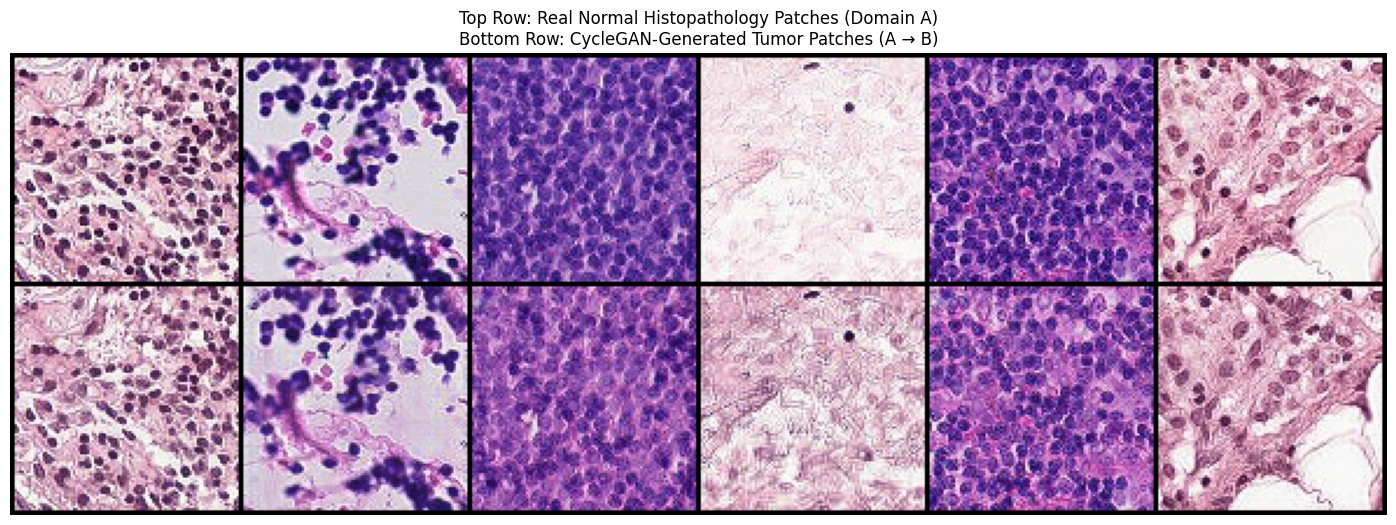

In [43]:
visualize_real_vs_generated(G_AB, loader_A, n=6)


In [44]:
torch.save({
    "G_AB": G_AB.state_dict(),
    "G_BA": G_BA.state_dict(),
    "epoch": 3
}, "final_cyclegan_epoch3.pth")
